<a href="https://colab.research.google.com/github/ParvJain108/EE604_Image_Processing/blob/main/A1_230740_Parv_Jain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1 Bit-Plane Slicing and Progressive Image Reconstruction**
---

1. Image Setup

--2026-08-15 16:43:23--  https://github.com/ParvJain108/EE604_Image_Processing/blob/main/HW1/image.jpg?raw=true
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/ParvJain108/EE604_Image_Processing/raw/refs/heads/main/HW1/image.jpg [following]
--2026-08-15 16:43:23--  https://github.com/ParvJain108/EE604_Image_Processing/raw/refs/heads/main/HW1/image.jpg
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ParvJain108/EE604_Image_Processing/refs/heads/main/HW1/image.jpg [following]
--2026-08-15 16:43:24--  https://raw.githubusercontent.com/ParvJain108/EE604_Image_Processing/refs/heads/main/HW1/image.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercon

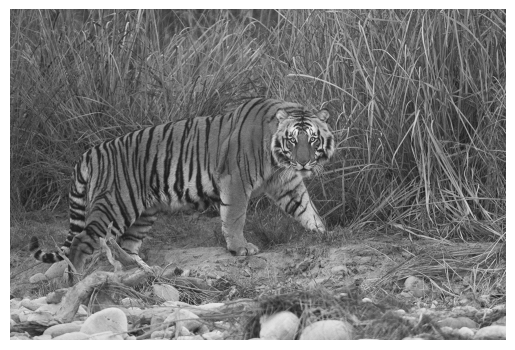

In [ ]:
#link to github repository where image is stored
!wget -O image.jpg "https://github.com/ParvJain108/EE604_Image_Processing/blob/main/HW1/image.jpg?raw=true"

import cv2 #OpenCV Python
import matplotlib.pyplot as plt #pyplot module in matplotlib
import numpy as np #numpy

img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE) #Reading image and storing intensity values in array

#Shape of image in terms of pixels (width, height)
print(img.shape)

#Checking for data type of pixel storage (must be uint8)
print(img.dtype)

#Display image
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

2. Bit Plane Slicing and Progressive Image Reconstruction

In [ ]:
import cv2
import numpy as np
import subprocess

#Video parameters
fps = 2  #frames per second in the output video file
hold_seconds = 1  #how long each of the 8 stages stays visible
frames_per_stage = fps * hold_seconds

height, width = img.shape
raw_path = 'Resultant_Video_raw.mp4'

#VideoWriter setup: codec, fps, frame size (width, height)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(raw_path, fourcc, fps, (width, height), isColor=False)

#Looping through each bit plane from MSB (7) to LSB (0)
#Ensure no garbage value in first iteration of loop
result_image = np.zeros_like(img)

#Loop
for i in range(7, -1, -1):

    #Extract the (i+1)-th bit plane and then right shift by i to bring the (i+1)-th bit to the LSB position,
    #then bitwise-AND with 1 to get either 0 or 1
    #Result Image is the Progressive Image Reconstruction result after each plane addition to previous step
    #after multiplication with weight of the bit plane
    result_image += ((img >> i) & 1)*(2**i)

    #Save frame for video file
    frame = result_image.astype(np.uint8)
    cv2.imwrite(f'stage_{8-i}_raw.png', frame)

    # Write to video (held for frames_per_stage frames)
    for _ in range(frames_per_stage):
        out.write(frame)

# Release the VideoWriter object
out.release()

subprocess.run([
    'ffmpeg', '-y', '-i', raw_path,
    '-c:v', 'libx264', '-profile:v', 'high', '-pix_fmt', 'yuv420p',
    '-r', str(fps), '-movflags', '+faststart',
    'Resultant_Video.mp4'
], check=True)

CompletedProcess(args=['ffmpeg', '-y', '-i', 'Resultant_Video_raw.mp4', '-c:v', 'libx264', '-profile:v', 'high', '-pix_fmt', 'yuv420p', '-r', '2', '-movflags', '+faststart', 'Resultant_Video.mp4'], returncode=0)

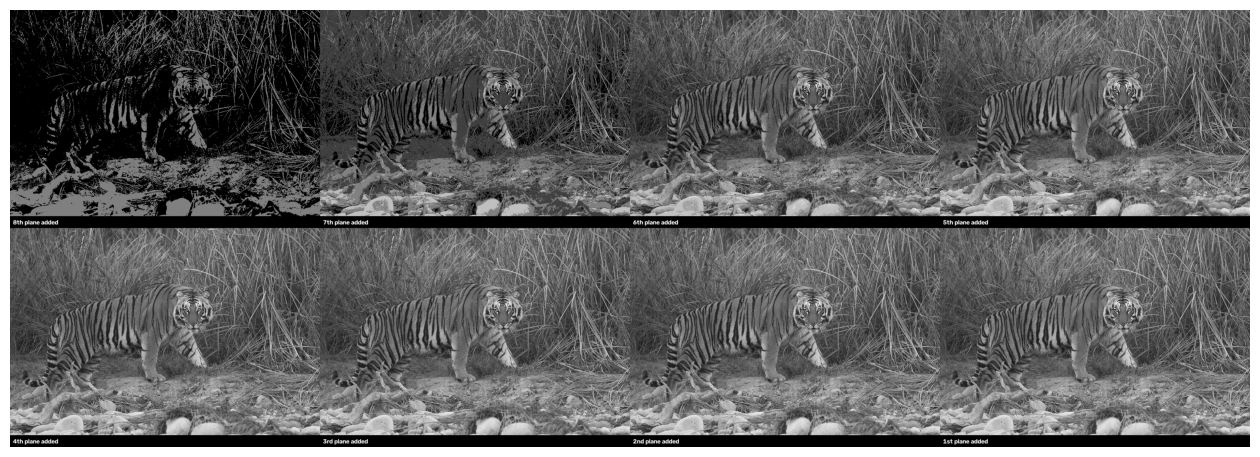

In [ ]:
#Images Display after each step
ordinals = ['8th', '7th', '6th', '5th', '4th', '3rd', '2nd', '1st']

titled_imgs = []
for n in range(1, 9):
    frame = cv2.imread(f'stage_{n}_raw.png', cv2.IMREAD_GRAYSCALE)

    frame_with_title = cv2.copyMakeBorder(frame, 0, 40, 0, 0, cv2.BORDER_CONSTANT, value=0)

    title_text = f"{ordinals[n-1]} plane added"
    cv2.putText(frame_with_title, title_text, (10, frame.shape[0] + 28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    titled_imgs.append(frame_with_title)

row1 = np.hstack(titled_imgs[0:4])
row2 = np.hstack(titled_imgs[4:8])
grid = np.vstack([row1, row2])

plt.figure(figsize=(16, 9))
plt.imshow(grid, cmap='gray')
plt.axis('off')
plt.savefig('all_stages_grid.png', dpi=150, bbox_inches='tight')
plt.show()

3. Video Details

In [ ]:
import os
print(os.path.getsize('Resultant_Video.mp4'), "bytes")
print(f"Video frame rate: {fps} fps")
print(f"Each stage held for: {hold_seconds} seconds")
print(f"Frames per stage: {frames_per_stage}")
print(f"Total video duration: {8 * hold_seconds} seconds")

1458534 bytes
Video frame rate: 2 fps
Each stage held for: 1 seconds
Frames per stage: 2
Total video duration: 8 seconds


---
**Q2 Image Degradation and Restoration Using Spatial Filters**
---

1. Image Setup

--2026-08-15 16:43:30--  https://github.com/ParvJain108/EE604_Image_Processing/blob/main/HW1/image2.png?raw=true
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/ParvJain108/EE604_Image_Processing/raw/refs/heads/main/HW1/image2.png [following]
--2026-08-15 16:43:31--  https://github.com/ParvJain108/EE604_Image_Processing/raw/refs/heads/main/HW1/image2.png
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ParvJain108/EE604_Image_Processing/refs/heads/main/HW1/image2.png [following]
--2026-08-15 16:43:31--  https://raw.githubusercontent.com/ParvJain108/EE604_Image_Processing/refs/heads/main/HW1/image2.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubus

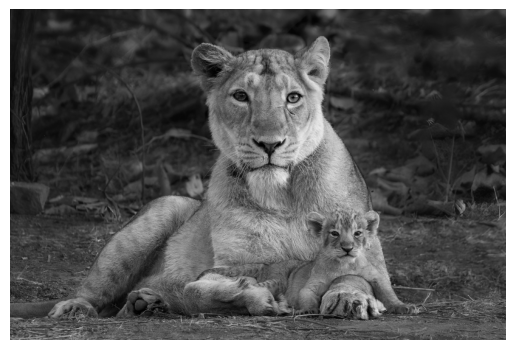

In [ ]:
#link to github repository where image is stored
!wget -O image2.png "https://github.com/ParvJain108/EE604_Image_Processing/blob/main/HW1/image2.png?raw=true"
img2 = cv2.imread('image2.png', cv2.IMREAD_GRAYSCALE) #Reading image and storing intensity values in array

#Shape of image in terms of pixels (width, height)
print(img2.shape)

#Checking for data type of pixel storage (must be uint8)
print(img2.dtype)

#Display image
plt.imshow(img2, cmap='gray')
plt.axis('off')
plt.show()

2. Gaussian Noise

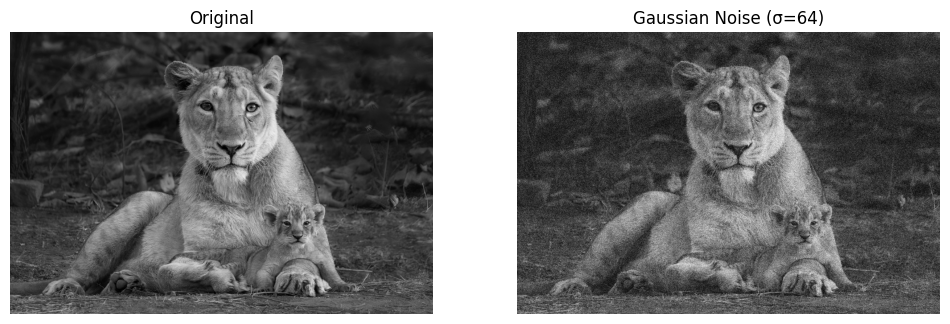

In [ ]:
mean = 0
sigma = 64 #High value taken to clearly spot difference

#Generate noise with same shape as image
gaussian_noise = np.random.normal(mean, sigma, img2.shape)

noisy_img = img2.astype(np.float64) + gaussian_noise   #math in float, to avoid uint8 overflow
noisy_img = np.clip(noisy_img, 0, 255)                 #to keep values in valid range
noisy_img = noisy_img.astype(np.uint8)                 #convert back to uint8 for filtering

#Displaying Original image and Corrupted image

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title(f'Gaussian Noise (σ={sigma})')
axes[1].axis('off')
plt.show()

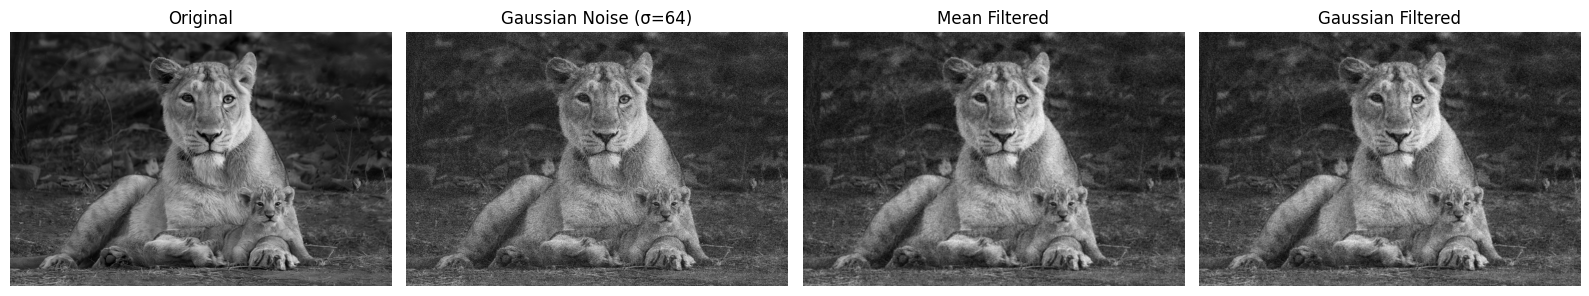

In [ ]:
# Mean filter
mean_filtered = cv2.blur(noisy_img, (7, 7))

# Gaussian filter
gaussian_filtered = cv2.GaussianBlur(noisy_img, (7, 7), sigmaX=2)

#Displaying Original image and  Corrected Images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title(f'Gaussian Noise (σ={sigma})')
axes[1].axis('off')

axes[2].imshow(mean_filtered, cmap='gray')
axes[2].set_title('Mean Filtered')
axes[2].axis('off')

axes[3].imshow(gaussian_filtered, cmap='gray')
axes[3].set_title('Gaussian Filtered')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

#Compare noisy image to original image
psnr_noisy = psnr(img2, noisy_img)
ssim_noisy = ssim(img2, noisy_img)

#Compare each filtered result to original image
psnr_mean = psnr(img2, mean_filtered)
ssim_mean = ssim(img2, mean_filtered)

psnr_gauss = psnr(img2, gaussian_filtered)
ssim_gauss = ssim(img2, gaussian_filtered)

print(f"Noisy:            PSNR={psnr_noisy:.2f}, SSIM={ssim_noisy:.4f}")
print(f"Mean filtered:    PSNR={psnr_mean:.2f}, SSIM={ssim_mean:.4f}")
print(f"Gaussian filtered: PSNR={psnr_gauss:.2f}, SSIM={ssim_gauss:.4f}")

Noisy:            PSNR=13.40, SSIM=0.0960
Mean filtered:    PSNR=23.50, SSIM=0.5145
Gaussian filtered: PSNR=23.61, SSIM=0.5178


A **Gaussian filter** is well-suited to Gaussian noise because it performs a local weighted averaging operation, which by the Central Limit Theorem reduces the variance of zero-mean, independent random noise the more samples (neighborhood pixels) are combined.

Additionally, because the Gaussian kernel's weighting decays smoothly with distance from the center pixel, it aligns with the assumption that nearby pixels in a natural image are likely to represent similar true intensity values, allowing it to suppress random noise while limiting distortion to genuine image structure such as edges.

A simple **Mean filter** relies on the same averaging principle and can perform comparably in raw noise suppression, but its uniform weighting makes it more prone to blurring edges than the Gaussian filter's smoothly-decaying kernel.

3. Salt and Pepper Noise

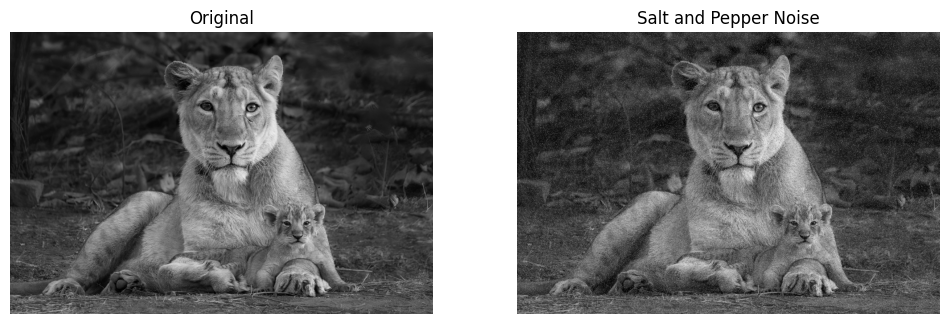

In [ ]:
#Generate noise with same shape as image

def add_salt_pepper_noise(image, salt_prob, pepper_prob):
    noisy = image.copy()

    # Salt: randomly select pixels and set to 255
    num_salt = int(salt_prob * image.size)
    salt_coords = [np.random.randint(0, dim, num_salt) for dim in image.shape]
    noisy[salt_coords[0], salt_coords[1]] = 255

    # Pepper: randomly select pixels and set to 0
    num_pepper = int(pepper_prob * image.size)
    pepper_coords = [np.random.randint(0, dim, num_pepper) for dim in image.shape]
    noisy[pepper_coords[0], pepper_coords[1]] = 0

    return noisy

sp_noisy = add_salt_pepper_noise(img2, salt_prob=0.05, pepper_prob=0.05)

#Displaying Original image and Corrupted image

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(sp_noisy, cmap='gray')
axes[1].set_title('Salt and Pepper Noise')
axes[1].axis('off')
plt.show()

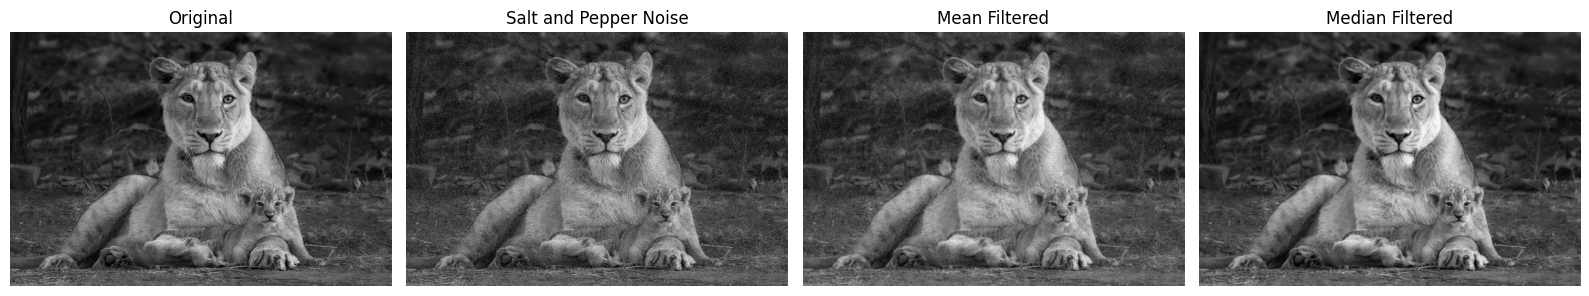

In [ ]:
#Mean filter
sp_mean_filtered = cv2.blur(sp_noisy, (7,7))

#Median filter
median_filtered = cv2.medianBlur(sp_noisy, 7)

#Displaying Original image and  Corrected Images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(sp_noisy, cmap='gray')
axes[1].set_title('Salt and Pepper Noise')
axes[1].axis('off')

axes[2].imshow(sp_mean_filtered, cmap='gray')
axes[2].set_title('Mean Filtered')
axes[2].axis('off')

axes[3].imshow(median_filtered, cmap='gray')
axes[3].set_title('Median Filtered')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Compare noisy image to original image
psnr_noisy_sp = psnr(img2, sp_noisy)
ssim_noisy_sp = ssim(img2, sp_noisy)

#Compare each filtered result to original image
psnr_mean_sp = psnr(img2, sp_mean_filtered)
ssim_mean_sp = ssim(img2, sp_mean_filtered)

psnr_median = psnr(img2, median_filtered)
ssim_median = ssim(img2, median_filtered)

print(f"Noisy:            PSNR={psnr_noisy_sp:.2f}, SSIM={ssim_noisy_sp:.4f}")
print(f"Mean filtered:    PSNR={psnr_mean_sp:.2f}, SSIM={ssim_mean_sp:.4f}")
print(f"Median filtered:  PSNR={psnr_median:.2f}, SSIM={ssim_median:.4f}")

Noisy:            PSNR=15.11, SSIM=0.1966
Mean filtered:    PSNR=24.32, SSIM=0.5540
Median filtered:  PSNR=26.25, SSIM=0.7230


**Median filtering** picks the middle value when all neighborhood pixels are sorted, this makes it robust to outliers, since one or two extreme salt/pepper pixels get outvoted by the majority of legitimate neighboring pixels and simply get discarded from the output, rather than dragging the result toward an extreme value the way a mean filter would.

4. Speckle Noise

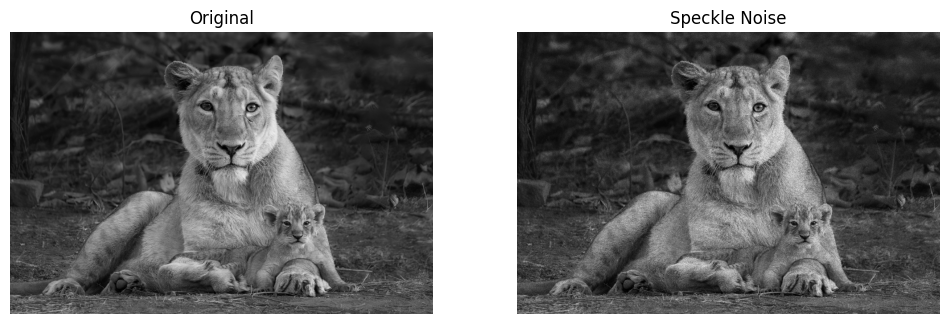

In [ ]:
# Generate multiplicative noise, same shape as image

def add_speckle_noise(image, sigma):

    noise = np.random.randn(*image.shape) * sigma   # zero-mean gaussian-distributed multiplier

    noisy = image.astype(np.float64) + image.astype(np.float64) * noise
    noisy = np.clip(noisy, 0, 255)
    return noisy.astype(np.uint8)

speckle_noisy = add_speckle_noise(img2, sigma=0.3)

#Displaying Original image and Corrupted image

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(speckle_noisy, cmap='gray')
axes[1].set_title('Speckle Noise')
axes[1].axis('off')
plt.show()

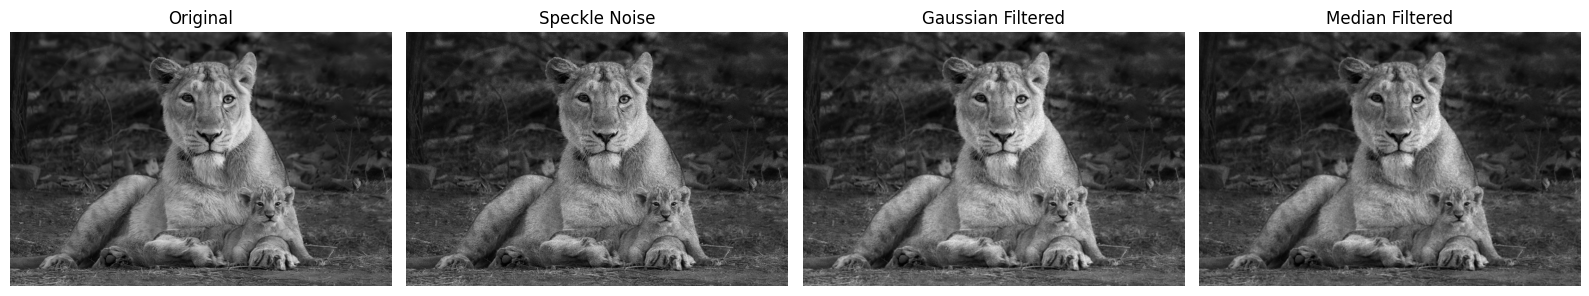

In [ ]:
#Gaussian filter
speckle_gaussian_filtered = cv2.GaussianBlur(speckle_noisy, (7, 7), sigmaX=2)

#Median filter
speckle_median_filtered = cv2.medianBlur(speckle_noisy, 7)

#Displaying Original image and  Corrected Images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(speckle_noisy, cmap='gray')
axes[1].set_title('Speckle Noise')
axes[1].axis('off')

axes[2].imshow(speckle_gaussian_filtered, cmap='gray')
axes[2].set_title('Gaussian Filtered')
axes[2].axis('off')

axes[3].imshow(speckle_median_filtered, cmap='gray')
axes[3].set_title('Median Filtered')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Compare noisy image to original image
psnr_noisy_speckle = psnr(img2, speckle_noisy)
ssim_noisy_speckle = ssim(img2, speckle_noisy)

#Compare each filtered result to original image
psnr_gaussian_speckle = psnr(img2, speckle_gaussian_filtered)
ssim_gaussian_speckle = ssim(img2, speckle_gaussian_filtered)

psnr_median_speckle = psnr(img2, speckle_median_filtered)
ssim_median_speckle = ssim(img2, speckle_median_filtered)

print(f"Noisy:                PSNR={psnr_noisy_speckle:.2f}, SSIM={ssim_noisy_speckle:.4f}")
print(f"Gaussian filtered:    PSNR={psnr_gaussian_speckle:.2f}, SSIM={ssim_gaussian_speckle:.4f}")
print(f"Median filtered:      PSNR={psnr_median_speckle:.2f}, SSIM={ssim_median_speckle:.4f}")

Noisy:                PSNR=20.20, SSIM=0.3989
Gaussian filtered:    PSNR=26.46, SSIM=0.7286
Median filtered:      PSNR=25.52, SSIM=0.6779


Speckle noise does not produce isolated extreme outlier pixels, it perturbs every pixel by a magnitude proportional to local intensity. Because median filtering's advantage lies specifically in rejecting outlier values, it offers no particular benefit here and can unnecessarily discard fine detail. **Gaussian filtering**'s local averaging is better matched to speckle's smoothly-varying, per-pixel perturbation.

5. Poisson Noise

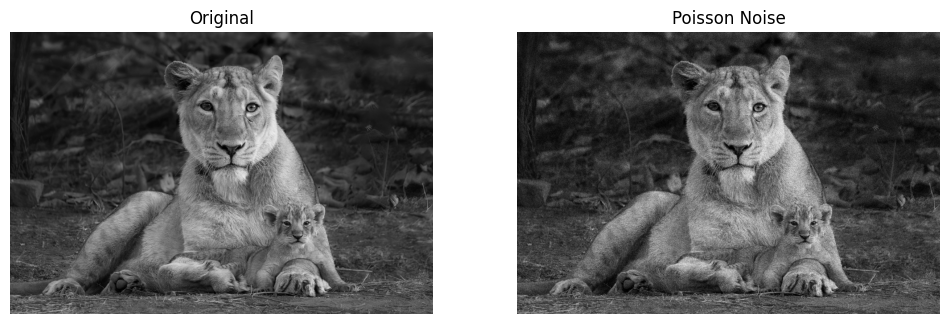

In [ ]:
#Poisson noise is signal-dependent
#np.random.poisson takes the pixel value itself as the strength parameter

def add_poisson_noise(image, peak):

    # Lower 'peak' = fewer simulated photons = stronger relative noise
    scaled = image.astype(np.float64) / 255.0 * peak  #math in float, to avoid uint8 overflow
    noisy = np.random.poisson(scaled) / peak * 255.0  #to keep values in valid range
    noisy = np.clip(noisy, 0, 255)                    #convert back to uint8 for filtering
    return noisy.astype(np.uint8)

p_noisy = add_poisson_noise(img2, peak = 20)

#Displaying Original image and Corrupted image

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(p_noisy, cmap='gray')
axes[1].set_title('Poisson Noise')
axes[1].axis('off')
plt.show()

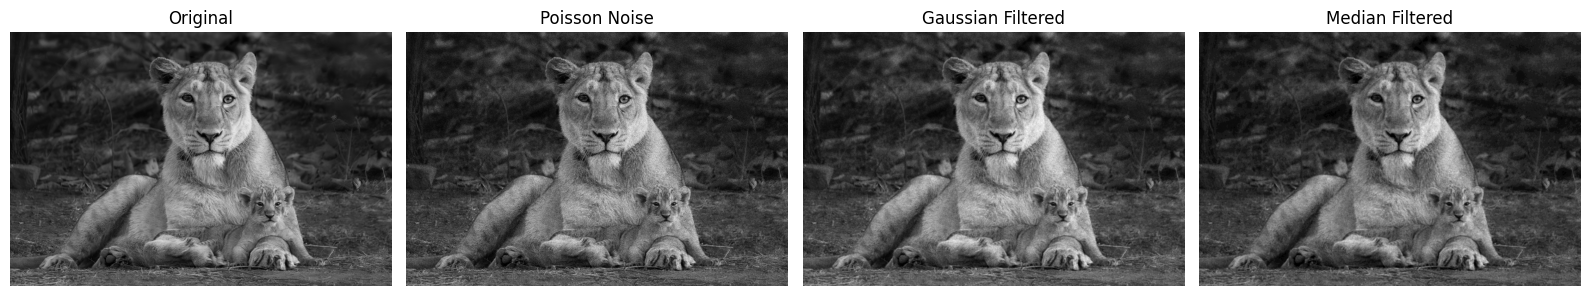

In [ ]:
#Gaussian filter
p_gaussian_filtered = cv2.GaussianBlur(p_noisy, (7, 7), sigmaX=2)

#Median filter
p_median_filtered = cv2.medianBlur(p_noisy, 7)

#Displaying Original image and  Corrected Images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(p_noisy, cmap='gray')
axes[1].set_title('Poisson Noise')
axes[1].axis('off')

axes[2].imshow(p_gaussian_filtered, cmap='gray')
axes[2].set_title('Gaussian Filtered')
axes[2].axis('off')

axes[3].imshow(p_median_filtered, cmap='gray')
axes[3].set_title('Median Filtered')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Compare noisy image to original image
psnr_noisy_p = psnr(img2, p_noisy)
ssim_noisy_p = ssim(img2, p_noisy)

#Compare each filtered result to original image
psnr_gaussian_p = psnr(img2, p_gaussian_filtered)
ssim_gaussian_p = ssim(img2, p_gaussian_filtered)

psnr_median_p = psnr(img2, p_median_filtered)
ssim_median_p = ssim(img2, p_median_filtered)

print(f"Noisy:                PSNR={psnr_noisy_p:.2f}, SSIM={ssim_noisy_p:.4f}")
print(f"Gaussian filtered:    PSNR={psnr_gaussian_p:.2f}, SSIM={ssim_gaussian_p:.4f}")
print(f"Median filtered:      PSNR={psnr_median_p:.2f}, SSIM={ssim_median_p:.4f}")

Noisy:                PSNR=18.62, SSIM=0.2450
Gaussian filtered:    PSNR=26.28, SSIM=0.6921
Median filtered:      PSNR=24.94, SSIM=0.5733


Poisson noise was simulated with peak=20 (a low-photon-count regime, representative of low-light imaging conditions), producing significant degradation . Since Poisson noise is signal-dependent but produces a smooth, distributed perturbation rather than discrete outlier pixels, a Gaussian filter's local averaging is well-suited to suppress it. Median filtering also improved the image but underperformed relative to Gaussian filtering, since its outlier-rejection mechanism offers no particular advantage against noise that lacks true outlier pixels.